In [246]:
SEARCH_DIR_PATH = "data/climb_box_2025-05-05_12-54-08"
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from search.save_data import DataSaver

data = DataSaver(SEARCH_DIR_PATH).load()
print(data.keys())

dict_keys(['avg_collision', 'iteration', 'log_prod_res', 'residuals', 'reward', 'run_close_loop', 'search_time', 'sequence', 'success_close_loop'])


In [247]:
def get_highest_collision_free_reward(data, N = 10):
    is_collision_free = [True if collision == 0 else False for collision in data["avg_collision"]]
    N_collision_free = sum(is_collision_free)
    print("Number of collision free found", N_collision_free)
    print("Average number of collision free per iteration", N_collision_free / data["iteration"][-1])
    
    highest_reward = max(np.array(data["reward"])[is_collision_free])
    highest_reward_index = data["reward"].index(highest_reward)
    print("Highest reward collision free:", highest_reward, "index:", highest_reward_index)

    sorted_reward = np.sort(np.array(data["reward"])[is_collision_free])
    for r in reversed(sorted_reward[-N:]):
        i =  data["reward"].index(r)
        print("Highest collision free reward:", i, "---", r)


def get_number_of_unique_solutions_found(data):
    solutions = data["sequence"]
    unique_solutions = []
    for sol in solutions:
        if not sol in unique_solutions:
            unique_solutions.append(sol)

    print("Number of unique solutions found:", len(unique_solutions))
    print("Total number of solutions", len(solutions))

In [248]:
get_highest_collision_free_reward(data)
get_number_of_unique_solutions_found(data)

Number of collision free found 20
Average number of collision free per iteration 0.06289308176100629
Highest reward collision free: 0.9483418857395002 index: 131
Highest collision free reward: 131 --- 0.9483418857395002
Highest collision free reward: 40 --- 0.9470951741742584
Highest collision free reward: 303 --- 0.41840748696096225
Highest collision free reward: 16 --- 0.3895031252168669
Highest collision free reward: 47 --- 0.36669950993715056
Highest collision free reward: 53 --- 0.2795325466782894
Highest collision free reward: 35 --- 0.23579887603694422
Highest collision free reward: 100 --- 0.21961712835882127
Highest collision free reward: 228 --- 0.20228987477889632
Highest collision free reward: 19 --- 0.19237302227428588
Number of unique solutions found: 319
Total number of solutions 319


In [249]:
def plot_collision_free(data):
    is_collision_free = [True if collision == 0 else False for collision in data["avg_collision"]]

    cum_sum_collision_free = np.cumsum(is_collision_free)

    plt.figure(figsize=(10, 5))
    plt.plot(data["iteration"], cum_sum_collision_free, label="Collision free", color="blue")
    plt.title("N collision free vs Iterations")
    plt.xlabel("Iterations")
    plt.ylabel("N collision free")
    plt.show()


    # Calculate the moving average for avg_collision
    window_size = 20  # Define the window size for the moving average
    moving_avg_collision = np.convolve(data["avg_collision"], np.ones(window_size)/window_size, mode='valid')

    # Plot both avg_collision and its moving average on the same graph
    plt.figure(figsize=(10, 5))
    plt.plot(data["iteration"], data["avg_collision"], label="Avg Collision", color="blue", alpha=0.1)
    plt.plot(data["iteration"][:len(moving_avg_collision)], moving_avg_collision, label="Moving Avg Collision", color="red")
    plt.title("Avg Collision and Moving Average vs Iterations")
    plt.xlabel("Iterations")
    plt.ylabel("Collision")
    plt.legend()
    plt.grid()
    plt.show()
    
def plot_reward(data):
    plt.figure(figsize=(10, 5))
    # Calculate the moving average for avg_collision
    window_size = 20  # Define the window size for the moving average
    moving_avg_collision = np.convolve(data["reward"], np.ones(window_size)/window_size, mode='valid')

    # Plot both avg_collision and its moving average on the same graph
    plt.figure(figsize=(10, 5))
    plt.plot(data["iteration"], data["reward"], label="reward", color="blue", alpha=0.1)
    plt.plot(data["iteration"][:len(moving_avg_collision)], moving_avg_collision, label="Moving avg reward", color="red")
    plt.title("Reward and Moving Average vs Iterations")
    plt.xlabel("Iterations")
    plt.ylabel("Reward")
    plt.legend()
    plt.grid()
    plt.show()


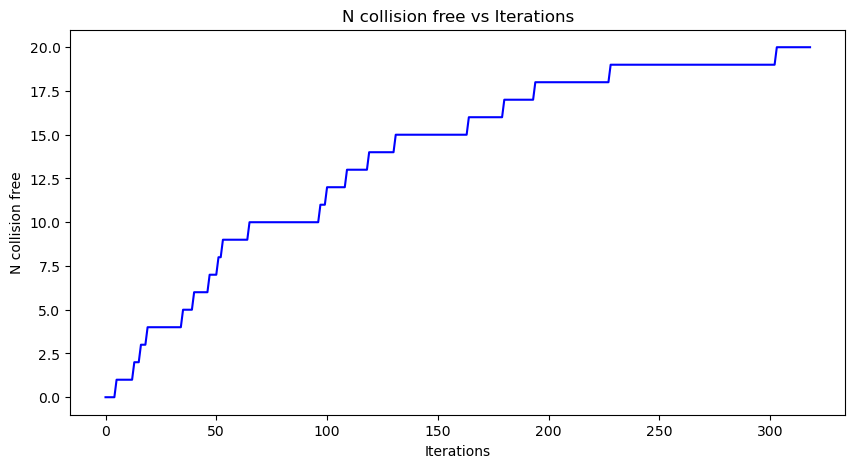

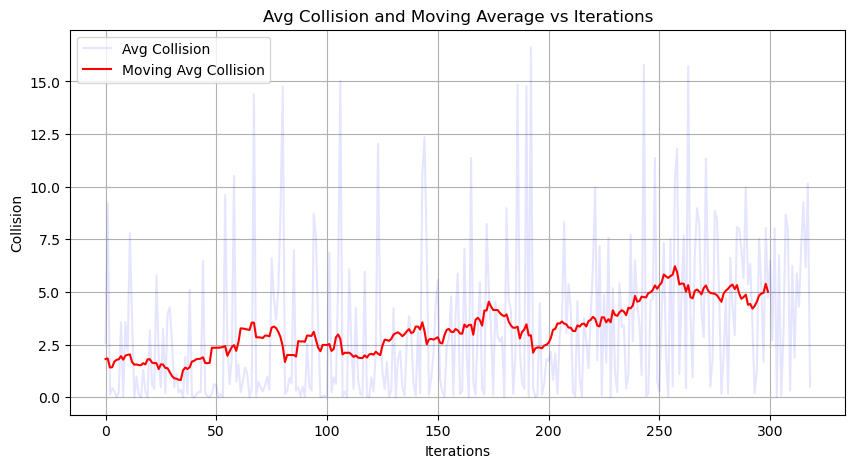

In [250]:
### PLOT NUMBER OF COLLISION FREE VS ITERATIONS
plot_collision_free(data)

<Figure size 1000x500 with 0 Axes>

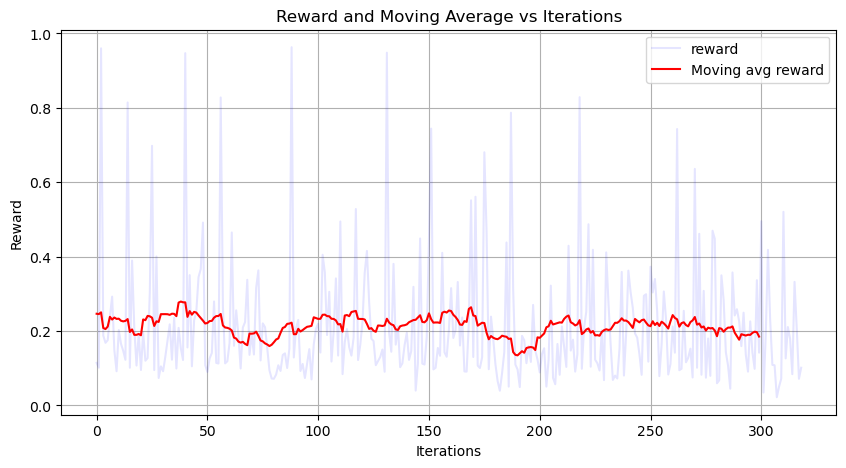

In [251]:
### PLOT REWARD VS ITERATIONS 
plot_reward(data)

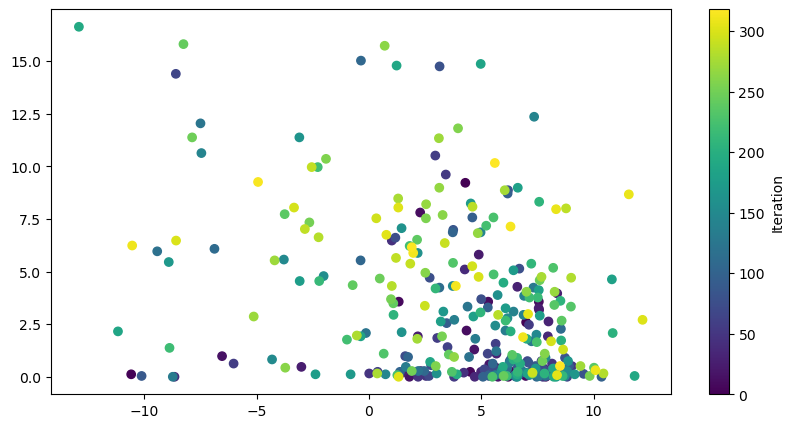

In [252]:
### AVG COLLISION VS RESIDUALS

plt.figure(figsize=(10, 5))
# plt.scatter(data["log_prod_res"], data["avg_collision"], label="Avg Collision", color="blue", marker="o")
sc = plt.scatter(data["log_prod_res"], data["avg_collision"], c=data["iteration"], cmap="viridis", marker="o")
plt.colorbar(sc, label="Iteration")

plt.show()

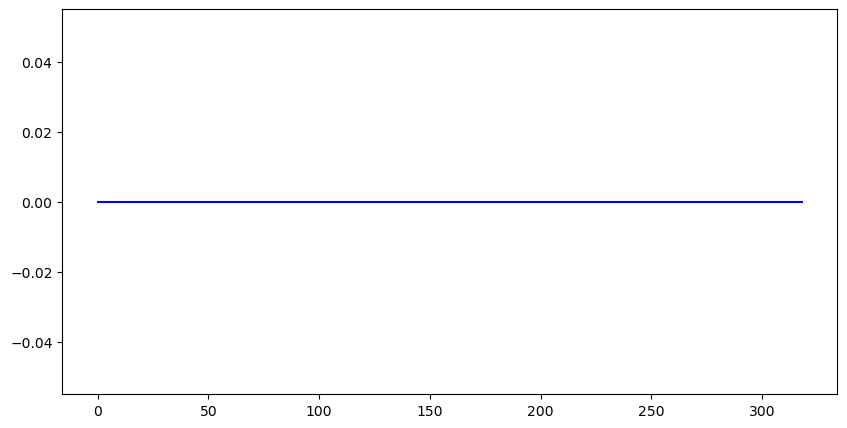

In [253]:
### RUN MPC VS RESIDUALS
cum_sum_close_loop = np.cumsum(data["run_close_loop"])

plt.figure(figsize=(10, 5))
plt.plot(data["iteration"], cum_sum_close_loop, label="Avg Collision", color="blue")
plt.show()

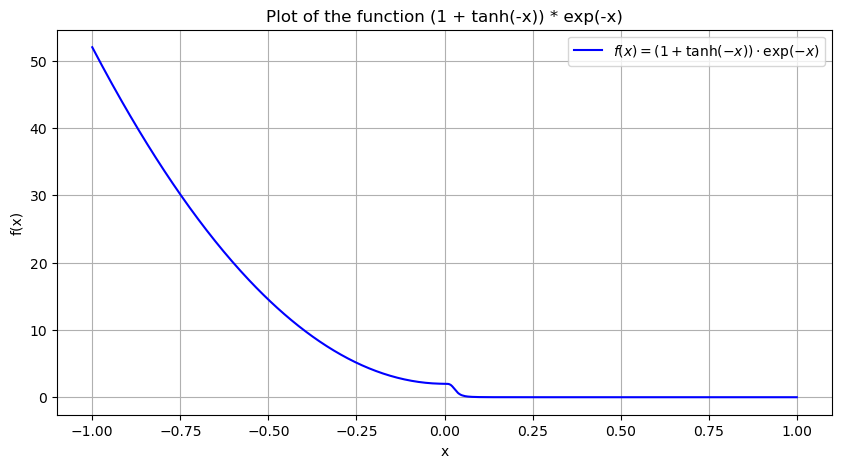

In [254]:
x = np.linspace(-1, 1, 500)  # Generate 500 points between -10 and 10
beta = 1/1000000
y = (beta / (beta + x**4))

# y = np.where(x < 0, x**2 + 1, y)


y = (1 + np.sign(x)) * y + (1 - np.sign(x)) * ((5*x)**2 + 1)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label=r"$f(x) = (1 + \tanh(-x)) \cdot \exp(-x)$", color="blue")
plt.title("Plot of the function (1 + tanh(-x)) * exp(-x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()
plt.show()

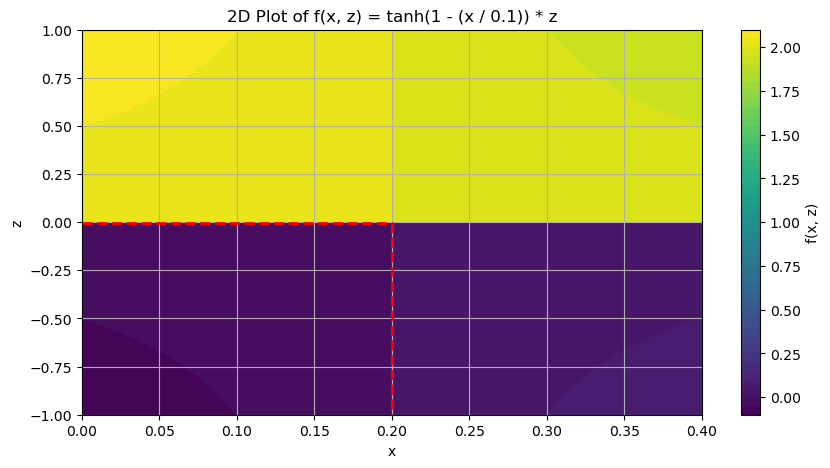

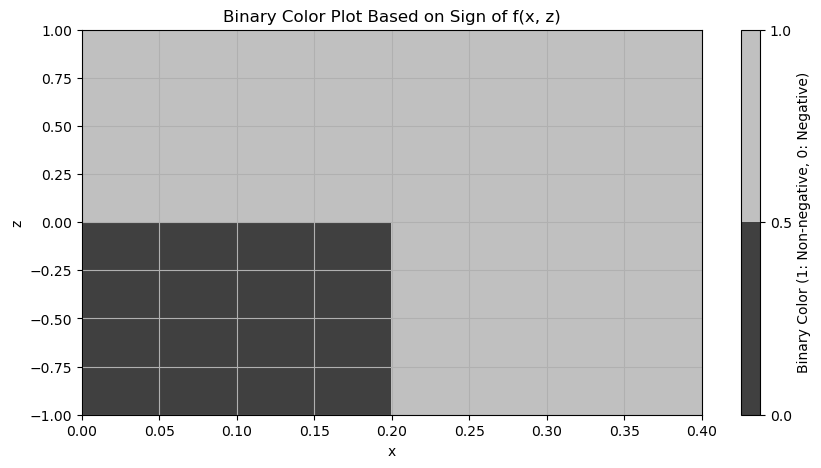

In [255]:
plane_size = 0.2
stiff = .1

def sigmoid(x, s=10):
    return 1  / (1 + np.exp(-s * x))

x = np.linspace(0, 2*plane_size, 500)  # Generate 500 points between -10 and 10
z = np.linspace(-1, 1, 500)  # Generate 500 points for z between -1 and 1
X, Z = np.meshgrid(x, z)  # Create a meshgrid for x and z
Y = (np.tanh(stiff*(1 - (X / plane_size))*Z)) + (np.sign(Z) + 1)
# Y = X * Z * sigmoid(-X+plane_size) * sigmoid(-Z)

plt.figure(figsize=(10, 5))
plt.contourf(X, Z, Y, levels=50, cmap="viridis")  # Create a filled contour plot
plt.colorbar(label="f(x, z)")
plt.title("2D Plot of f(x, z) = tanh(1 - (x / 0.1)) * z")
plt.xlabel("x")
plt.ylabel("z")
plt.grid()


plt.contour(X, Z, Y, levels=[0], colors='red', linestyles='dashed', linewidths=2)
plt.show()
binary_color = np.where(Y >= 0, 1, 0)  # Assign 1 for non-negative values, 0 for negative values

plt.figure(figsize=(10, 5))
plt.contourf(X, Z, binary_color, levels=1, cmap="gray")  # Create a binary color plot
plt.colorbar(label="Binary Color (1: Non-negative, 0: Negative)")
plt.title("Binary Color Plot Based on Sign of f(x, z)")
plt.xlabel("x")
plt.ylabel("z")
plt.grid()
plt.show()

In [256]:
N = 100
children = np.arange(N)
%timeit np.random.shuffle(children)


1.55 μs ± 35.9 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
